In [2]:
!pip install kagglehub
import kagglehub
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
path = kagglehub.dataset_download("aryashah2k/breast-ultrasound-images-dataset")
print(path)

IMG_SIZE = 128

data = []
labels = []

dataset_path = os.path.join(path,"Dataset_BUSI_with_GT")

classes = ["benign","malignant","normal"]

for label,cls in enumerate(classes):

    folder = os.path.join(dataset_path,cls)

    for file in os.listdir(folder):

        if "mask" in file:
            continue

        img_path = os.path.join(folder,file)

        img = cv2.imread(img_path)
        img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
        img = img/255.0

        data.append(img)
        labels.append(label)

data = np.array(data)
labels = np.array(labels)

print("Dataset shape:",data.shape)


Using Colab cache for faster access to the 'breast-ultrasound-images-dataset' dataset.
/kaggle/input/breast-ultrasound-images-dataset
Dataset shape: (780, 128, 128, 3)


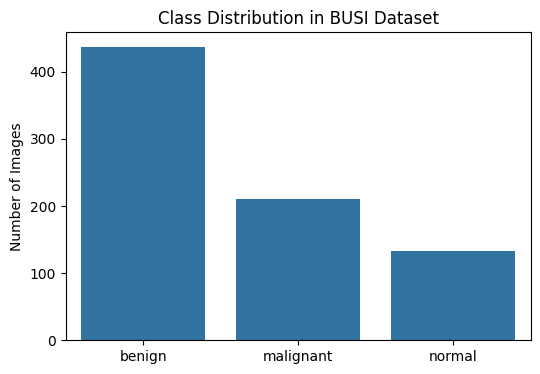

In [4]:
class_counts = pd.Series(labels).value_counts()

plt.figure(figsize=(6,4))

sns.barplot(
    x=["benign","malignant","normal"],
    y=class_counts.values
)

plt.title("Class Distribution in BUSI Dataset")
plt.ylabel("Number of Images")
plt.show()

In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    data, labels,
    test_size=0.30,
    stratify=labels,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:",X_train.shape)
print("Validation:",X_val.shape)
print("Test:",X_test.shape)

Train: (546, 128, 128, 3)
Validation: (117, 128, 128, 3)
Test: (117, 128, 128, 3)


In [6]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print("Class weights:",class_weights)

Class weights: {0: np.float64(0.5947712418300654), 1: np.float64(1.2380952380952381), 2: np.float64(1.956989247311828)}


In [7]:
datagen = ImageDataGenerator(
    rotation_range=8,
    horizontal_flip=True,
    zoom_range=0.08
)
datagen.fit(X_train)

In [8]:
benign = X_train[y_train==0]
malignant = X_train[y_train==1]
normal = X_train[y_train==2]


target_size = len(benign)


def augment_class(images,target):

    augmented = list(images)

    while len(augmented) < target:

        img = images[np.random.randint(len(images))]
        img = img.reshape((1,128,128,3))

        aug_iter = datagen.flow(img,batch_size=1)

        augmented.append(next(aug_iter)[0])

    return np.array(augmented)


malignant_aug = augment_class(malignant,target_size)
normal_aug = augment_class(normal,target_size)

X_balanced = np.concatenate([benign,malignant_aug,normal_aug])

y_balanced = np.concatenate([
    np.zeros(len(benign)),
    np.ones(len(malignant_aug)),
    np.full(len(normal_aug),2)
])

In [1]:
def create_model():

    model = tf.keras.Sequential()


    model.add(tf.keras.layers.DepthwiseConv2D((3,3),activation='relu',input_shape=(128,128,3)))
    model.add(tf.keras.layers.Conv2D(16,(1,1),activation='relu'))
    model.add(tf.keras.layers.MaxPooling2D())


    model.add(tf.keras.layers.DepthwiseConv2D((3,3),activation='relu'))
    model.add(tf.keras.layers.Conv2D(32,(1,1),activation='relu'))
    model.add(tf.keras.layers.MaxPooling2D())


    model.add(tf.keras.layers.DepthwiseConv2D((3,3),activation='relu'))
    model.add(tf.keras.layers.Conv2D(64,(1,1),activation='relu'))
    model.add(tf.keras.layers.MaxPooling2D())


    model.add(tf.keras.layers.Flatten())
    model.add(tf.keras.layers.Dense(64,activation='relu'))
    model.add(tf.keras.layers.Dropout(0.4))
    model.add(tf.keras.layers.Dense(3,activation='softmax'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


In [9]:
model_baseline = create_model()

history_baseline = model_baseline.fit(
    X_train,y_train,
    epochs=12,
    validation_data=(X_val,y_val)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_depthwise_conv.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Epoch 1/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 23s 804ms/step - accuracy: 0.5495 - loss: 1.0335 - val_accuracy: 0.5556 - val_loss: 0.9865
Epoch 2/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 467ms/step - accuracy: 0.5604 - loss: 1.0012 - val_accuracy: 0.5556 - val_loss: 0.9942
Epoch 3/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 374ms/step - accuracy: 0.5586 - loss: 1.0053 - val_accuracy: 0.5556 - val_loss: 0.9827
Epoch 4/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 439ms/step - accuracy: 0.5604 - loss: 0.9961 - val_accuracy: 0.5556 - val_loss: 0.9806
Epoch 5/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 361ms/step - accuracy: 0.5604 - loss: 0.9915 - val_accuracy: 0.5556 - val_loss: 0.9807
Epoch 6/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 378ms/step - accuracy: 0.5604 - loss: 0.9947 - val_accuracy: 0.5556 - val_loss: 0.9805
Epoch 7/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 418ms/step - accuracy: 0.5604 - loss: 0.9896 - val_accuracy: 0.5556 - val_loss: 0.9771
Epoch 8/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 452ms/step - accuracy: 0.5604 - loss: 0.9873 - val_accuracy

In [10]:
model_aug = create_model()

history_aug = model_aug.fit(
    X_balanced,y_balanced,
    epochs=12,
    validation_data=(X_val,y_val)
)

Epoch 1/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 18s 544ms/step - accuracy: 0.3377 - loss: 1.0986 - val_accuracy: 0.5812 - val_loss: 1.0940
Epoch 2/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 432ms/step - accuracy: 0.3627 - loss: 1.0957 - val_accuracy: 0.3333 - val_loss: 1.0955
Epoch 3/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 428ms/step - accuracy: 0.3943 - loss: 1.0915 - val_accuracy: 0.5897 - val_loss: 1.0700
Epoch 4/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 20s 422ms/step - accuracy: 0.4477 - loss: 1.0654 - val_accuracy: 0.5043 - val_loss: 1.0455
Epoch 5/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 20s 420ms/step - accuracy: 0.4706 - loss: 1.0269 - val_accuracy: 0.5983 - val_loss: 0.9504
Epoch 6/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 21s 428ms/step - accuracy: 0.4858 - loss: 1.0016 - val_accuracy: 0.5726 - val_loss: 0.9593
Epoch 7/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 419ms/step - accuracy: 0.5011 - loss: 0.9815 - val_accuracy: 0.5641 - val_loss: 0.9335
Epoch 8/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 427ms/step - accuracy: 0.5196 - loss: 0.9741 - val_accu

In [11]:
model_weights = create_model()

history_weights = model_weights.fit(
    X_train,y_train,
    epochs=12,
    validation_data=(X_val,y_val),
    class_weight=class_weights
)

Epoch 1/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 408ms/step - accuracy: 0.1758 - loss: 1.0999 - val_accuracy: 0.1709 - val_loss: 1.0991
Epoch 2/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 450ms/step - accuracy: 0.1703 - loss: 1.0987 - val_accuracy: 0.1709 - val_loss: 1.1001
Epoch 3/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 413ms/step - accuracy: 0.1703 - loss: 1.0981 - val_accuracy: 0.1709 - val_loss: 1.1027
Epoch 4/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 375ms/step - accuracy: 0.1703 - loss: 1.0987 - val_accuracy: 0.1709 - val_loss: 1.1006
Epoch 5/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 359ms/step - accuracy: 0.1703 - loss: 1.0990 - val_accuracy: 0.1709 - val_loss: 1.0993
Epoch 6/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 391ms/step - accuracy: 0.1740 - loss: 1.0986 - val_accuracy: 0.1709 - val_loss: 1.1000
Epoch 7/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 437ms/step - accuracy: 0.1758 - loss: 1.0987 - val_accuracy: 0.1709 - val_loss: 1.0993
Epoch 8/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 359ms/step - accuracy: 0.2088 - loss: 1.0984 - val_accurac

In [12]:
model_both = create_model()

history_both = model_both.fit(
    X_balanced,y_balanced,
    epochs=12,
    validation_data=(X_val,y_val),
    class_weight=class_weights
)

Epoch 1/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 15s 434ms/step - accuracy: 0.3312 - loss: 1.2958 - val_accuracy: 0.1709 - val_loss: 1.4575
Epoch 2/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 413ms/step - accuracy: 0.3312 - loss: 1.2824 - val_accuracy: 0.1709 - val_loss: 1.3616
Epoch 3/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 404ms/step - accuracy: 0.3420 - loss: 1.2532 - val_accuracy: 0.1709 - val_loss: 1.3779
Epoch 4/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 11s 384ms/step - accuracy: 0.3943 - loss: 1.2006 - val_accuracy: 0.2650 - val_loss: 1.3789
Epoch 5/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 411ms/step - accuracy: 0.4336 - loss: 1.1690 - val_accuracy: 0.2735 - val_loss: 1.4053
Epoch 6/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 424ms/step - accuracy: 0.4717 - loss: 1.1095 - val_accuracy: 0.3162 - val_loss: 1.3637
Epoch 7/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 20s 423ms/step - accuracy: 0.4858 - loss: 1.0949 - val_accuracy: 0.3077 - val_loss: 1.3294
Epoch 8/12
29/29 ━━━━━━━━━━━━━━━━━━━━ 19s 376ms/step - accuracy: 0.4902 - loss: 1.0495 - val_accu

In [13]:
pred1 = np.argmax(model_baseline.predict(X_test),axis=1)
pred2 = np.argmax(model_aug.predict(X_test),axis=1)
pred3 = np.argmax(model_weights.predict(X_test),axis=1)
pred4 = np.argmax(model_both.predict(X_test),axis=1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step


3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step


In [14]:
print("BASELINE")
print(classification_report(y_test,pred1,target_names=classes))

print("AUGMENTATION")
print(classification_report(y_test,pred2,target_names=classes))

print("CLASS WEIGHTS")
print(classification_report(y_test,pred3,target_names=classes))

print("AUG + WEIGHTS")
print(classification_report(y_test,pred4,target_names=classes))

BASELINE
              precision    recall  f1-score   support

      benign       0.56      1.00      0.72        66
   malignant       0.00      0.00      0.00        31
      normal       0.00      0.00      0.00        20

    accuracy                           0.56       117
   macro avg       0.19      0.33      0.24       117
weighted avg       0.32      0.56      0.41       117

AUGMENTATION
              precision    recall  f1-score   support

      benign       0.66      0.56      0.61        66
   malignant       0.44      0.61      0.51        31
      normal       0.28      0.25      0.26        20

    accuracy                           0.52       117
   macro avg       0.46      0.47      0.46       117
weighted avg       0.54      0.52      0.52       117

CLASS WEIGHTS
              precision    recall  f1-score   support

      benign       0.58      0.94      0.72        66
   malignant       0.00      0.00      0.00        31
      normal       0.50      0.25      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [15]:
def plot_cm(y_true,y_pred,title):

    cm = confusion_matrix(y_true,y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(cm,
                annot=True,
                fmt='d',
                xticklabels=classes,
                yticklabels=classes)

    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

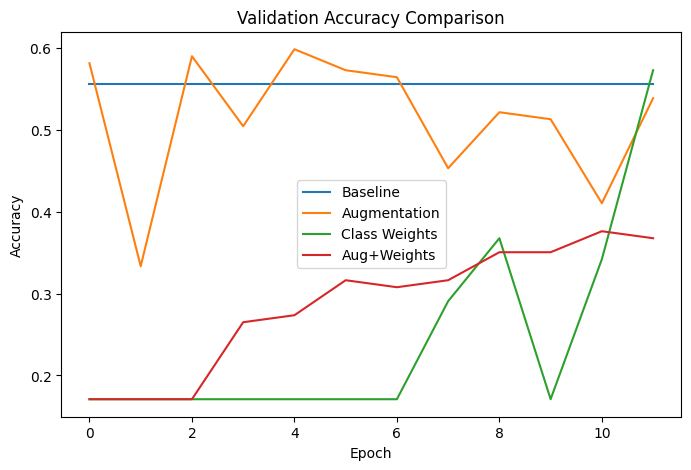

In [16]:
plt.figure(figsize=(8,5))

plt.plot(history_baseline.history['val_accuracy'],label="Baseline")
plt.plot(history_aug.history['val_accuracy'],label="Augmentation")
plt.plot(history_weights.history['val_accuracy'],label="Class Weights")
plt.plot(history_both.history['val_accuracy'],label="Aug+Weights")

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

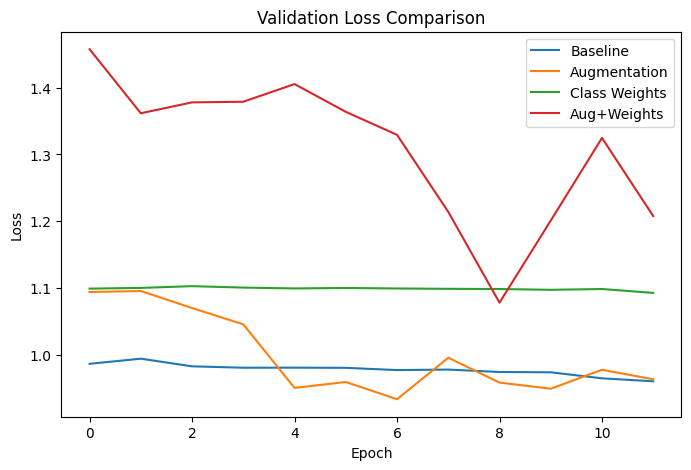

In [17]:
plt.figure(figsize=(8,5))

plt.plot(history_baseline.history['val_loss'],label="Baseline")
plt.plot(history_aug.history['val_loss'],label="Augmentation")
plt.plot(history_weights.history['val_loss'],label="Class Weights")
plt.plot(history_both.history['val_loss'],label="Aug+Weights")

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.5641 - loss: 0.9628
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.5214 - loss: 0.9717
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 188ms/step - accuracy: 0.5726 - loss: 1.0936
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 180ms/step - accuracy: 0.3675 - loss: 1.2818


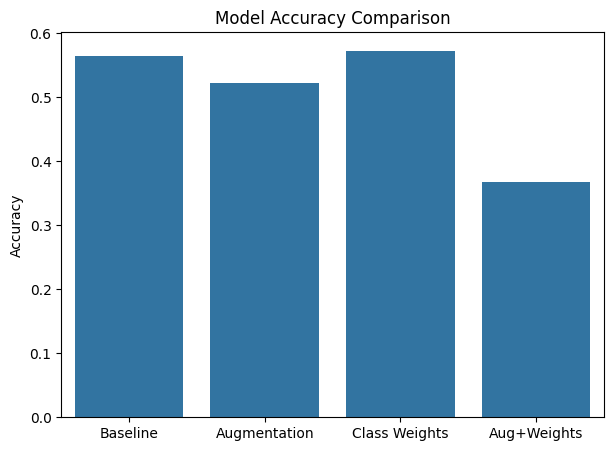

In [18]:
acc1 = model_baseline.evaluate(X_test,y_test)[1]
acc2 = model_aug.evaluate(X_test,y_test)[1]
acc3 = model_weights.evaluate(X_test,y_test)[1]
acc4 = model_both.evaluate(X_test,y_test)[1]

models = ["Baseline","Augmentation","Class Weights","Aug+Weights"]

accuracies = [acc1,acc2,acc3,acc4]

plt.figure(figsize=(7,5))

sns.barplot(x=models,y=accuracies)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

The depthwise separable CNN demonstrated significantly different behavior compared to the standard CNN. While the normal CNN achieved higher accuracy, it exhibited bias toward the majority class. In contrast, the depthwise CNN showed extreme sensitivity to class imbalance, completely failing to detect minority classes in the baseline configuration. However, when class balancing techniques such as targeted augmentation and class weighting were applied, the depthwise CNN showed substantial improvements in minority class recall. This indicates that depthwise architectures are more dependent on proper data balancing and benefit significantly from such techniques, although they may introduce instability if overcompensated.